### NYC Flights 2013 – Exploring Patterns in Flight Delays:

This notebook analyses flight delays for over 300,000 departures from New York City in 2013 using the nycflights13 dataset. We explore how delays vary by month, time of day, airline, distance, weather conditions, and aircraft age, and highlight when delays are most severe and which factors are most strongly associated with poor on‑time performance.

### Objective

- Understand flight delays in NYC in 2013.
- Explore which airlines, airports, times, or aircraft characteristics are associated with higher delays.
- Summarize insights visually and in tables.


In [1]:
#Load libraries
library(nycflights13)
library(tidyverse)
library(lubridate)
library(dplyr)
library(ggplot2)
library(mgcv)
library(scales)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: nlme




Attaching package: ‘nlme’




The following object is masked from ‘package:dplyr’:

    collapse




This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.




Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard




The following object is masked from ‘package:readr’:

    col_factor




In [2]:
#Peek at datasets
head(flights)
head(airlines)
head(weather)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00


carrier,name
<chr>,<chr>
9E,Endeavor Air Inc.
AA,American Airlines Inc.
AS,Alaska Airlines Inc.
B6,JetBlue Airways
DL,Delta Air Lines Inc.
EV,ExpressJet Airlines Inc.


origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
EWR,2013,1,1,1,39.02,26.06,59.37,270,10.35702,NA,0,1012.0,10,2013-01-01 01:00:00
EWR,2013,1,1,2,39.02,26.96,61.63,250,8.05546,NA,0,1012.3,10,2013-01-01 02:00:00
EWR,2013,1,1,3,39.02,28.04,64.43,240,11.50780,NA,0,1012.5,10,2013-01-01 03:00:00
EWR,2013,1,1,4,39.92,28.04,62.21,250,12.65858,NA,0,1012.2,10,2013-01-01 04:00:00
EWR,2013,1,1,5,39.02,28.04,64.43,260,12.65858,NA,0,1011.9,10,2013-01-01 05:00:00
EWR,2013,1,1,6,37.94,28.04,67.21,240,11.50780,NA,0,1012.4,10,2013-01-01 06:00:00


In [3]:
#Data Cleaning / Preparation

#Add cancelled column
flights <- flights %>%
  mutate(cancelled = is.na(dep_delay))

#Filter active flights
flights_active <- flights %>%
  filter(!cancelled)

In [4]:
flights_joined <- flights_active %>%
left_join(airlines, by = "carrier") %>%
left_join(planes, by = "tailnum")%>%
left_join(weather, by = c("origin", "month", "day", "hour"))

In [5]:
#Count flights per airline, origin, and destination
#first, we find active flights 

#Flights per airline
flights_joined %>%
  group_by(name) %>%  
  summarise(num_flights = n()) %>%
  arrange(desc(num_flights))

#Flights per origin
flights_joined %>%
  group_by(origin) %>%
  summarise(num_flights = n()) %>%
  arrange(desc(num_flights))

#Flights per destination
flights_joined %>%
  group_by(dest) %>%
  summarise(num_flights = n()) %>%
  arrange(desc(num_flights))

name,num_flights
<chr>,<int>
United Air Lines Inc.,57979
JetBlue Airways,54169
ExpressJet Airlines Inc.,51356
Delta Air Lines Inc.,47761
American Airlines Inc.,32093
Envoy Air,25163
US Airways Inc.,19873
Endeavor Air Inc.,17416
Southwest Airlines Co.,12083


origin,num_flights
<chr>,<int>
EWR,117596
JFK,109416
LGA,101509


dest,num_flights
<chr>,<int>
ATL,16898
ORD,16642
LAX,16076
BOS,15049
MCO,13982
CLT,13698
SFO,13230
FLL,11934
MIA,11633


In [6]:
#Flights by airline
flights_joined %>%
  group_by(carrier) %>%
  summarise(
    avg_dep_delay = mean(dep_delay, na.rm = TRUE),
    median_dep_delay = median(dep_delay, na.rm = TRUE),
    avg_arr_delay = mean(arr_delay, na.rm = TRUE),
    median_arr_delay = median(arr_delay, na.rm = TRUE)
  ) %>%
  arrange(desc(avg_arr_delay))

#Overall summary (all flights)
flights_joined %>%
  summarise(
    avg_dep_delay = mean(dep_delay, na.rm = TRUE),
    median_dep_delay = median(dep_delay, na.rm = TRUE),
    avg_arr_delay = mean(arr_delay, na.rm = TRUE),
    median_arr_delay = median(arr_delay, na.rm = TRUE)
  )

carrier,avg_dep_delay,median_dep_delay,avg_arr_delay,median_arr_delay
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
F9,20.215543,0.5,21.9207048,6
FL,18.726075,1.0,20.1159055,5
EV,19.955390,-1.0,15.7964311,-1
YV,18.996330,-2.0,15.5569853,-2
OO,12.586207,-6.0,11.9310345,-7
MQ,10.552041,-3.0,10.7747334,-1
WN,17.711744,1.0,9.6491199,-3
B6,13.022522,-1.0,9.4579733,-3
9E,16.725769,-2.0,7.3796692,-7


avg_dep_delay,median_dep_delay,avg_arr_delay,median_arr_delay
<dbl>,<dbl>,<dbl>,<dbl>
12.63907,-2,6.895377,-5


In [7]:
#Cancellation rates

#Overall cancellation rate
flights %>%
  mutate(cancelled = is.na(dep_delay)) %>%
  summarise(cancellation_rate = mean(cancelled, na.rm = TRUE))

#Cancellation rate by airline
flights %>%
  group_by(carrier) %>%
  summarise(cancellation_rate = mean(cancelled, na.rm = TRUE)) %>%
  arrange(desc(cancellation_rate))

cancellation_rate
<dbl>
0.02451184


carrier,cancellation_rate
<chr>,<dbl>
OO,0.093750000
YV,0.093178037
9E,0.056554713
EV,0.052000074
MQ,0.046747736
US,0.032284768
FL,0.022392638
AA,0.019432308
WN,0.015641548


### Visualizations

This notebook explores departure and arrival delays for NYC flights in 2013 using the nycflights13 dataset. I examine delay patterns by month, time of day, airline, distance, weather, and aircraft age to understand when and why delays are most likely to occur.
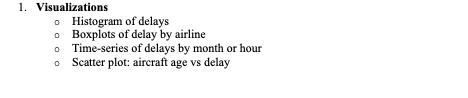
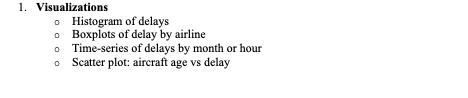
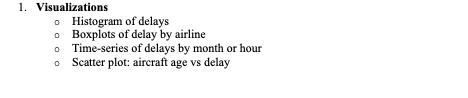
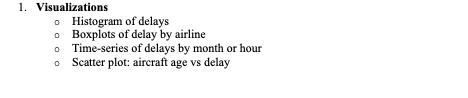

#### Histogram of departure delays
Here we look at the overall distribution of departure delays to see how often flights leave early, on time, slightly late, or extremely late.

Warning message:
“Removed 610 rows containing non-finite outside the scale range (`stat_bin()`).”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


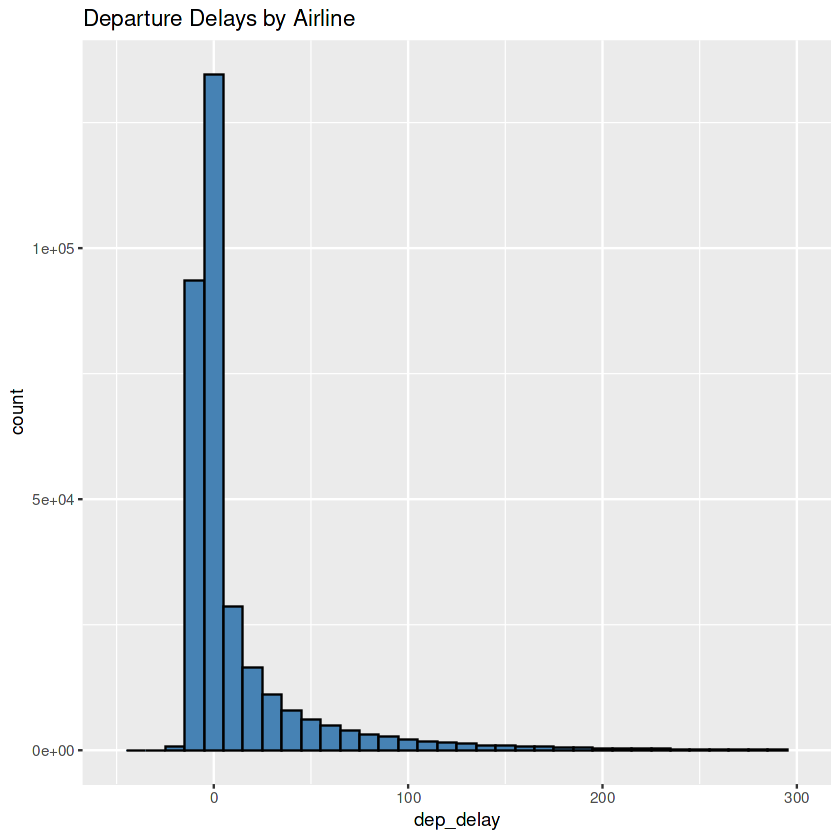

In [8]:
#Histogram of delays
ggplot(flights_joined, aes(x = dep_delay)) +
  geom_histogram(binwidth = 10, position = "dodge",fill = "steelblue", color = "black") +
  xlim(-50, 300) +
  labs(title = "Departure Delays by Airline")

#### Histogram of arrival delays
This chart shows the distribution of arrival delays, helping us understand how frequently flights arrive early or late and how heavy the tail of extreme delays is.

Warning message:
“Removed 2897 rows containing non-finite outside the scale range (`stat_bin()`).”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


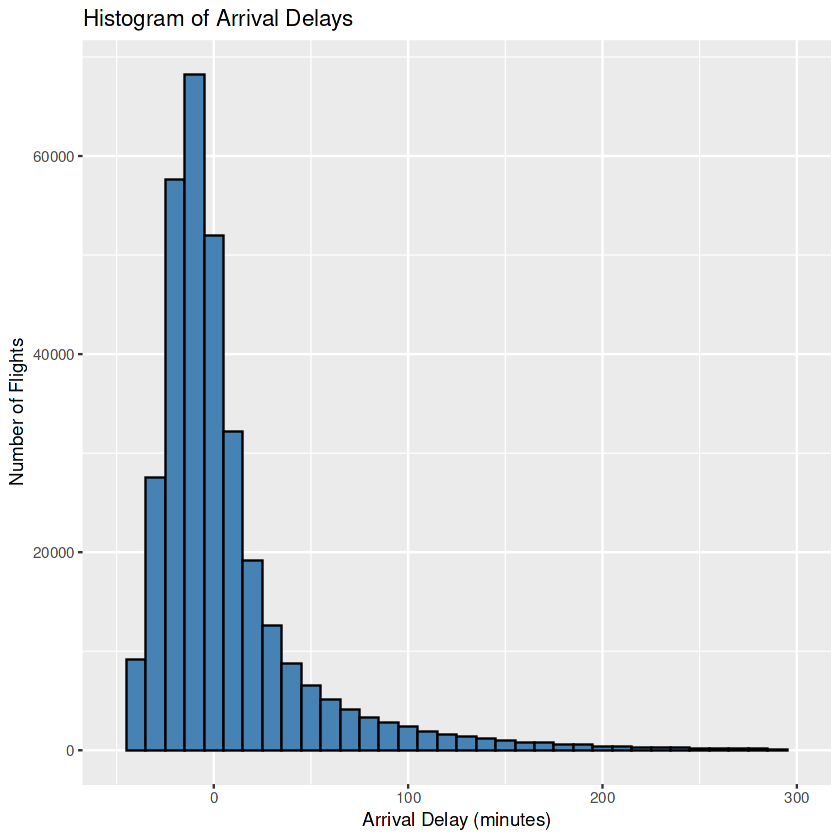

In [9]:
#Histogram of arrival delays
ggplot(flights_joined, aes(x = arr_delay)) +
  geom_histogram(binwidth = 10, fill = "steelblue", color = "black") +
  xlim(-50, 300) +
  labs(title = "Histogram of Arrival Delays", x = "Arrival Delay (minutes)", y = "Number of Flights")

#### Histogram of departure delays by airline
Here we compare the distribution of departure delays across airlines, highlighting carriers with more on‑time departures versus those with many heavily delayed flights.

Warning message:
“Removed 610 rows containing non-finite outside the scale range (`stat_bin()`).”


Warning message:
“Removed 32 rows containing missing values or values outside the scale range
(`geom_bar()`).”


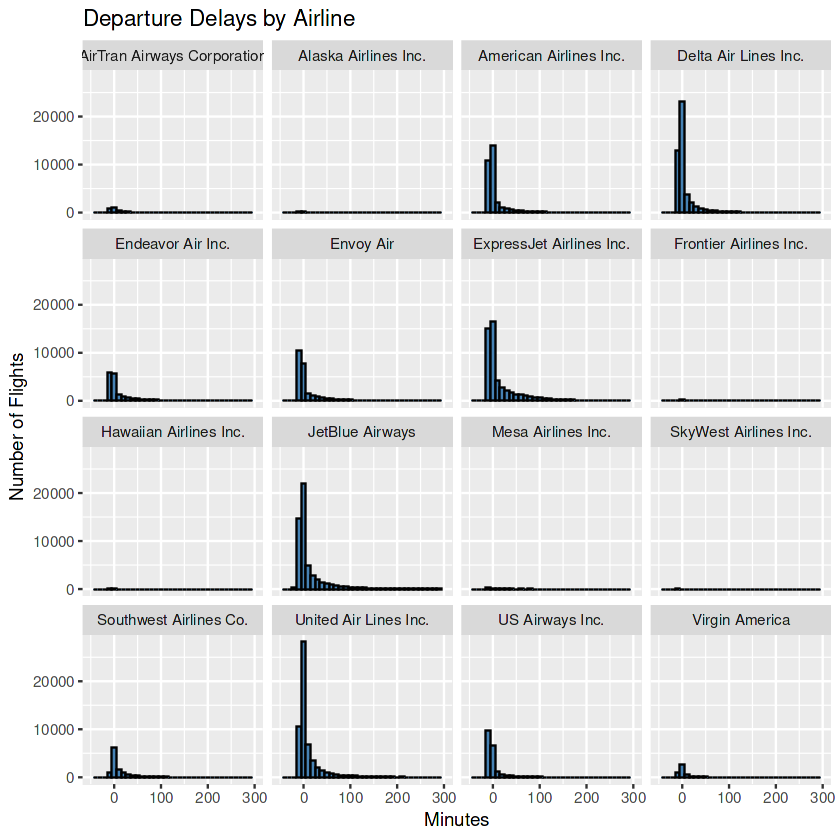

In [10]:
#Histogram of departure delays by airline
ggplot(flights_joined, aes(x = dep_delay)) +
  geom_histogram(binwidth = 10, fill = "steelblue", color = "black") +
  facet_wrap(~name) +
  xlim(-50, 300) +
  labs(title = "Departure Delays by Airline", x = "Minutes", y = "Number of Flights")

Note: Some histograms produce warnings such as “Removed 610 rows containing non‑finite values outside the scale range (stat_bin())” and “Removed 32 rows containing values outside the scale range (geom_bar()). These occur because flights with missing or extremely large/small delay values fall outside the plotted range, so ggplot automatically drops them while still showing the main distribution of delays.


#### Departure delays (including all flights)
This histogram includes all flights, including those with missing or extreme delay values, to give a complete picture of departure delay behaviour in the dataset.

Warning message:
“Removed 8255 rows containing non-finite outside the scale range (`stat_bin()`).”


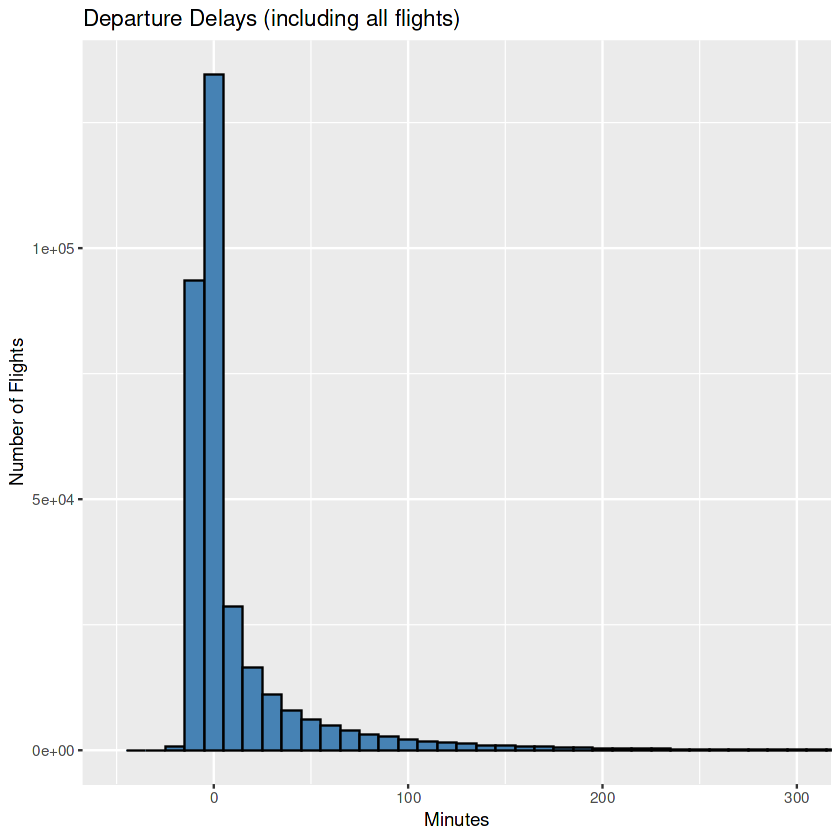

In [11]:
#Histogram of departure delays (including all flights)
ggplot(flights, aes(x = dep_delay)) +
  geom_histogram(binwidth = 10, fill = "steelblue", color = "black") +
  coord_cartesian(xlim = c(-50, 300)) +
  labs(title = "Departure Delays (including all flights)", x = "Minutes", y = "Number of Flights")

Note: Some histograms show warnings such as “Removed 8,255 rows containing non‑finite values outside the scale range (stat_bin()).” These arise because flights with missing or extremely large/small delay values fall outside the plotted range, so ggplot automatically excludes them from the histogram. This trimming focuses the view on the main bulk of flights without changing the underlying summary statistics.


#### Departure delays (excluding cancelled flights)
Here we focus only on flights that actually departed, excluding cancellations, so we can analyse the delay experience for passengers who flew.

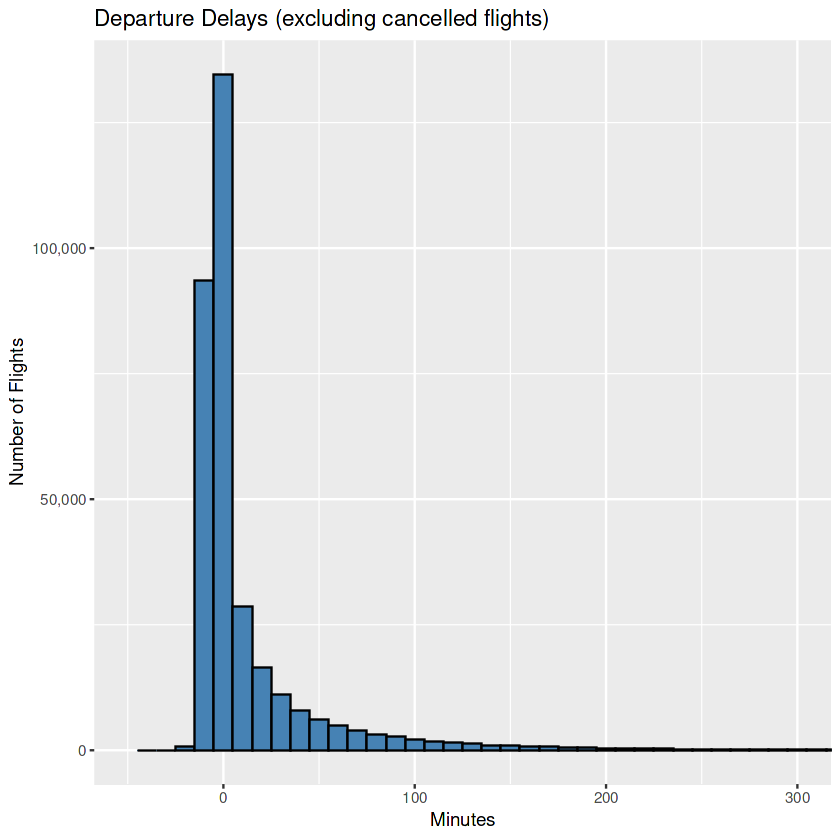

In [12]:
#Histogram of delays (excluding cancelled flights)
ggplot(flights %>% filter(!is.na(dep_delay)), aes(x = dep_delay)) +
  geom_histogram(binwidth = 10, fill = "steelblue", color = "black") +
  coord_cartesian(xlim = c(-50, 300)) +
  scale_x_continuous(labels = function(x) x) +
  scale_y_continuous(labels = scales::comma) +
  labs(title = "Departure Delays (excluding cancelled flights)", x = "Minutes", y = "Number of Flights")

#### Departure delays by airline (boxplot)
This boxplot summarizes departure delays for each airline, making it easy to compare typical delays and the spread of performance between carriers.

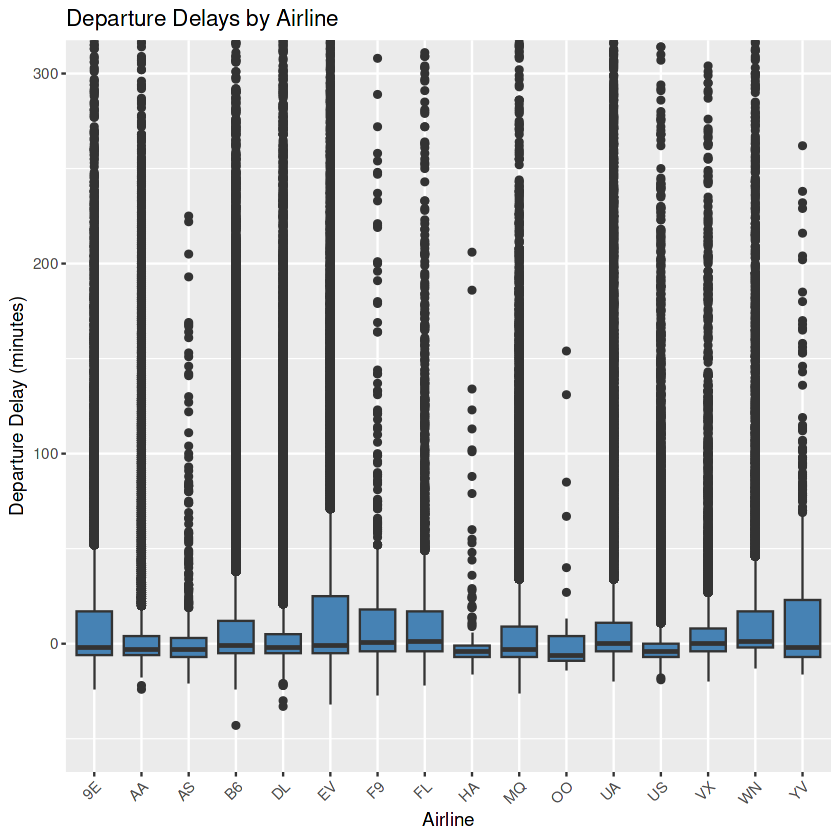

In [13]:
#Boxplot of departure delays by airline
ggplot(flights %>% filter(!is.na(dep_delay)), aes(x = carrier, y = dep_delay)) +
  geom_boxplot(fill = "steelblue") +
  coord_cartesian(ylim = c(-50, 300)) +  # focus on main range
  labs(
    title = "Departure Delays by Airline",
    x = "Airline",
    y = "Departure Delay (minutes)"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

#### Arrival delays by airline (boxplot)
Here we compare arrival delays by airline, showing which carriers tend to deliver passengers closer to schedule and which suffer more severe arrival delays.

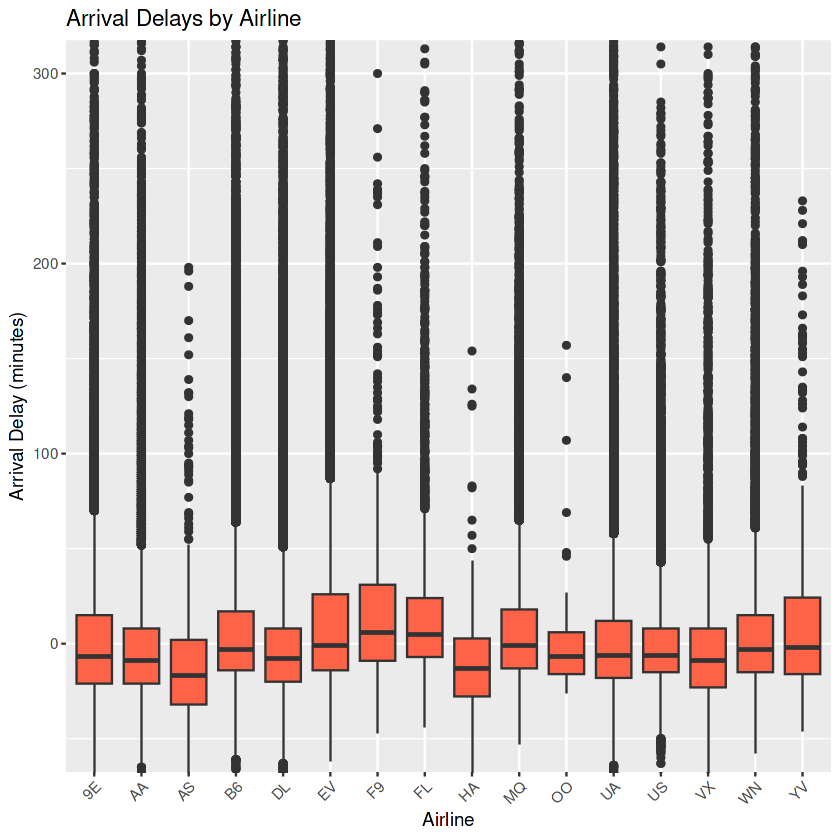

In [14]:
#Boxplot of arrival delays by airline
ggplot(flights %>% filter(!is.na(arr_delay)), aes(x = carrier, y = arr_delay)) +
  geom_boxplot(fill = "tomato") +
  coord_cartesian(ylim = c(-50, 300)) +
  labs(
    title = "Arrival Delays by Airline",
    x = "Airline",
    y = "Arrival Delay (minutes)"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

#### Average Departure Delay by Month
Here we track how average departure delay changes across the year to see which months experience the worst on‑time performance and whether there are clear seasonal patterns.

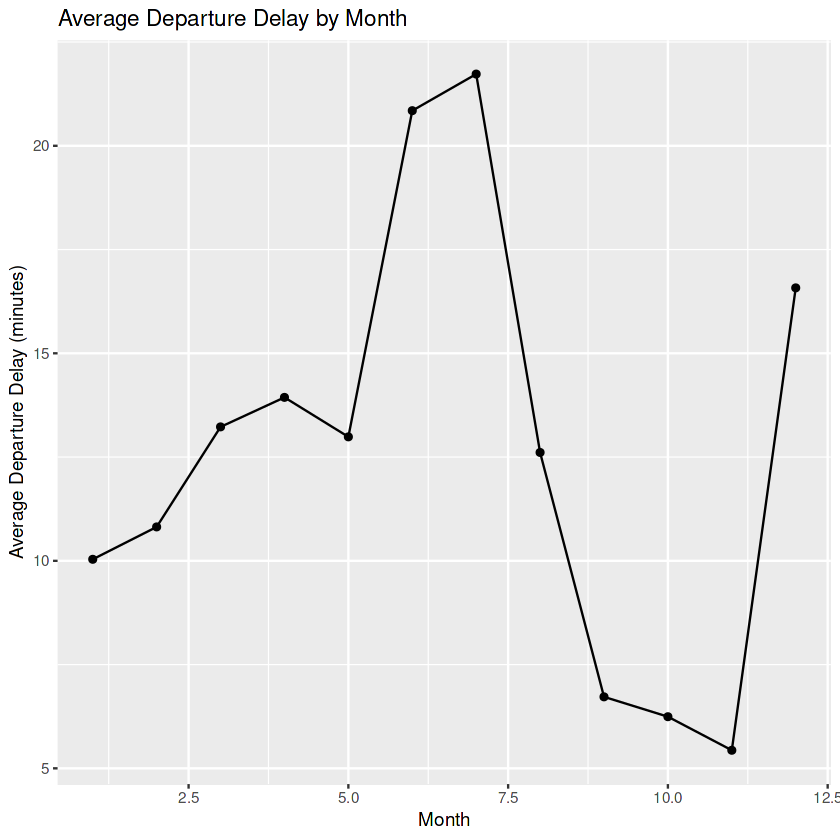

In [15]:
#Average depsrture delay (By Month)
monthly_delays <- flights %>%
  group_by(month) %>%
  summarise(
    avg_dep_delay = mean(dep_delay, na.rm = TRUE),
    flights = n()
  )
ggplot(monthly_delays, aes(x = month, y = avg_dep_delay)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Departure Delay by Month",
    x = "Month",
    y = "Average Departure Delay (minutes)"
  )

#### Average Departure Delay by Hour
Here we look at how average departure delay changes by scheduled departure hour to see whether delays start small in the morning and build up as the day progresses.

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


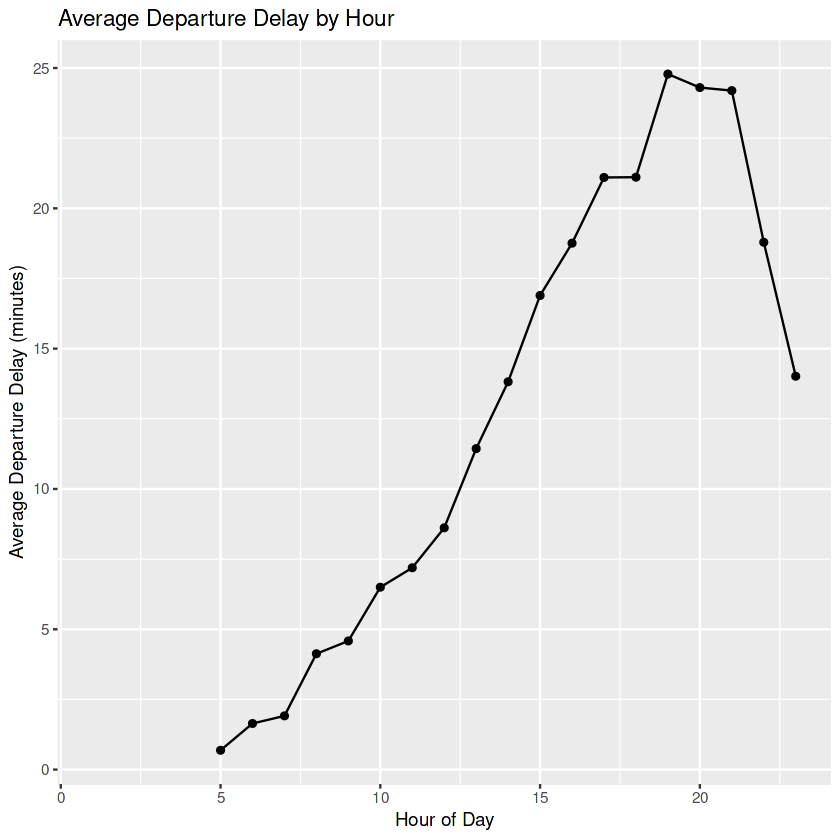

In [16]:
#Average department delay (By Hour)
hourly_delays <- flights %>%
  group_by(hour) %>%
  summarise(
    avg_dep_delay = mean(dep_delay, na.rm = TRUE),
    flights = n()
  )
ggplot(hourly_delays, aes(x = hour, y = avg_dep_delay)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Departure Delay by Hour",
    x = "Hour of Day",
    y = "Average Departure Delay (minutes)"
  )

Note: Some line plots generate warnings such as “Removed 1 row containing missing values or values outside the scale range (geom_line()/geom_point()). These occur because one hour/month has a missing or extreme value, so ggplot drops that single point without affecting the overall trend.”


#### Average Departure vs Delay by Month
Here we track how average departure delay changes across the year to see which months experience the worst on‑time performance and whether there are clear seasonal patterns.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


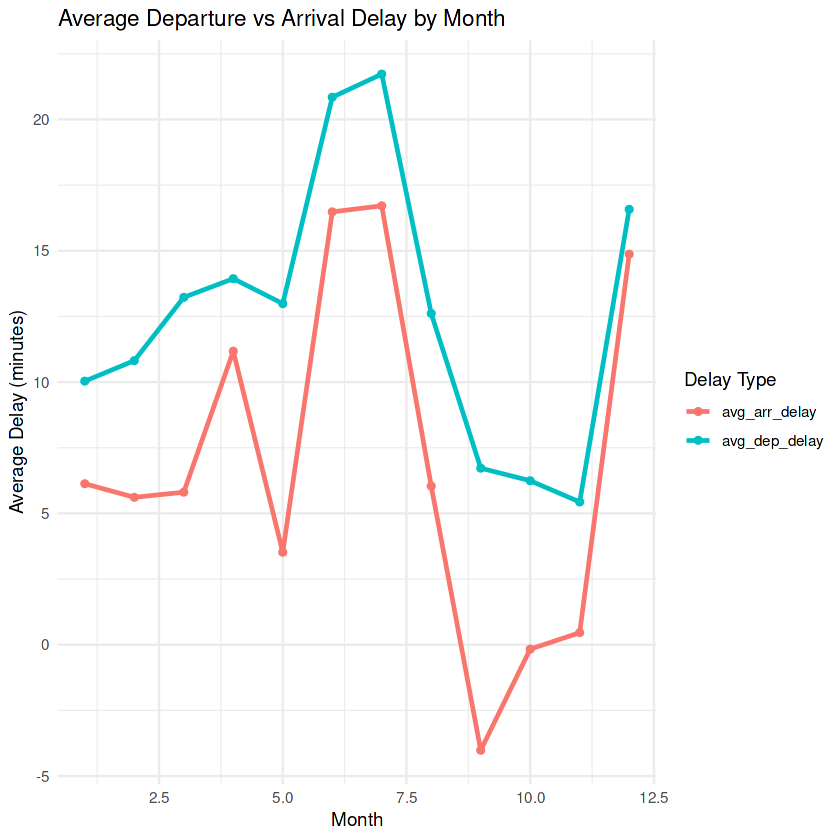

In [17]:
#Average departure vs arrival delay (By Month)
monthly_delays <- flights %>%
  group_by(month) %>%
  summarise(
    avg_dep_delay = mean(dep_delay, na.rm = TRUE),
    avg_arr_delay = mean(arr_delay, na.rm = TRUE),
    sd_dep_delay  = sd(dep_delay, na.rm = TRUE),
    flights = n()
  )
monthly_long <- monthly_delays %>%
  select(month, avg_dep_delay, avg_arr_delay) %>%
  pivot_longer(
    cols = c(avg_dep_delay, avg_arr_delay),
    names_to = "type",
    values_to = "delay"
  )
ggplot(monthly_long, aes(x = month, y = delay, color = type)) +
  geom_line(size = 1) +
  geom_point() +
  labs(
    title = "Average Departure vs Arrival Delay by Month",
    x = "Month",
    y = "Average Delay (minutes)",
    color = "Delay Type"
  ) +
  theme_minimal()

#### Volatility of monthly departure delays
Volatility of Departure Delays by Month<br>
Here we measure the volatility of departure delays using the standard deviation by month, so we can see in which months delay outcomes are most unpredictable versus more stable.

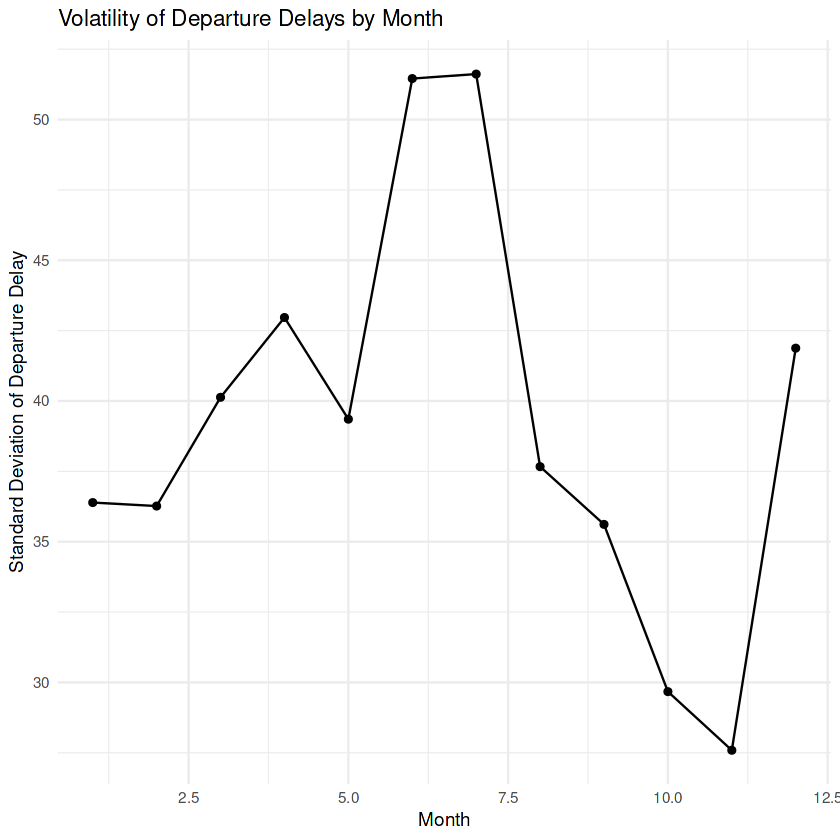

In [18]:
#Volatility of monthly departure delays(standart deviation by month)
ggplot(monthly_delays, aes(x = month, y = sd_dep_delay)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Volatility of Departure Delays by Month",
    x = "Month",
    y = "Standard Deviation of Departure Delay"
  ) +
  theme_minimal()

#### Average Departure Delay by Hour
Here we look at how average departure delay changes by scheduled departure hour to see whether delays start small in the morning and build up as the day progresses.

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


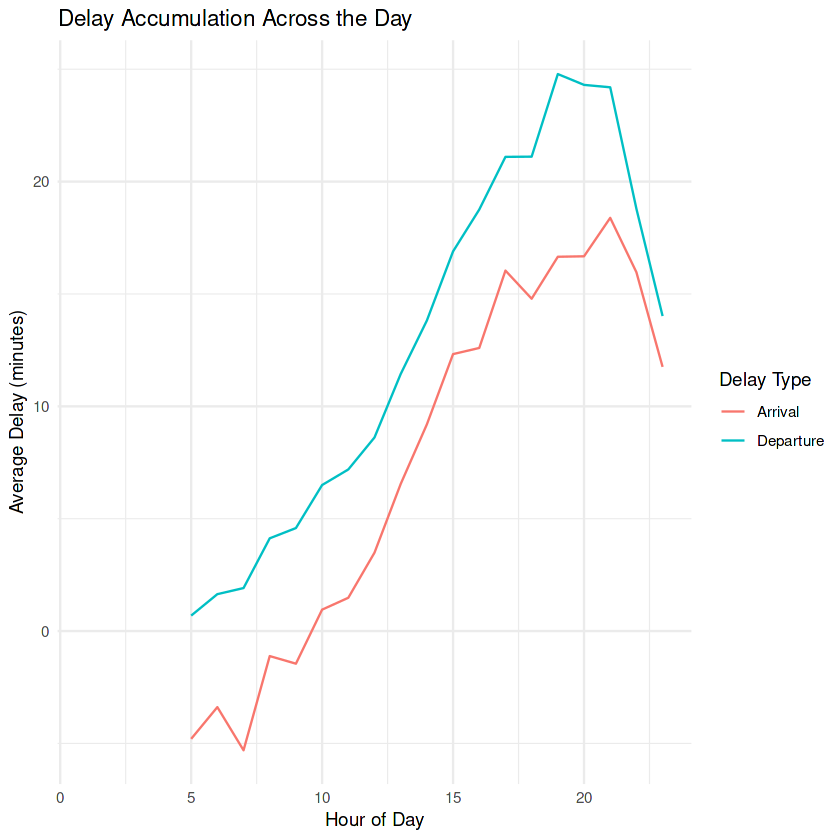

In [19]:
#Delay accumulation across the day(average departure delay by hour)
hourly_delays <- flights %>%
  group_by(hour) %>%
  summarise(
    avg_dep_delay = mean(dep_delay, na.rm = TRUE),
    avg_arr_delay = mean(arr_delay, na.rm = TRUE),
    sd_dep_delay  = sd(dep_delay, na.rm = TRUE),
    flights = n()
  )
ggplot(hourly_delays, aes(x = hour)) +
  geom_line(aes(y = avg_dep_delay, color = "Departure")) +
  geom_line(aes(y = avg_arr_delay, color = "Arrival")) +
  labs(
    title = "Delay Accumulation Across the Day",
    x = "Hour of Day",
    y = "Average Delay (minutes)",
    color = "Delay Type"
  ) +
  theme_minimal()

Note: Some of the line charts produce warnings such as “Removed 1 row containing missing values or values outside the scale range (geom_line()).” These occur because a small number of hours or months have missing or extreme delay values that fall outside the plotted axis range, so ggplot automatically drops those points. This does not affect the overall patterns shown in the charts.

#### Average Departure vs Arrival Delay by Month
This chart compares monthly average departure and arrival delays, showing how late departures translate into late arrivals and whether certain months amplify or dampen those effects.

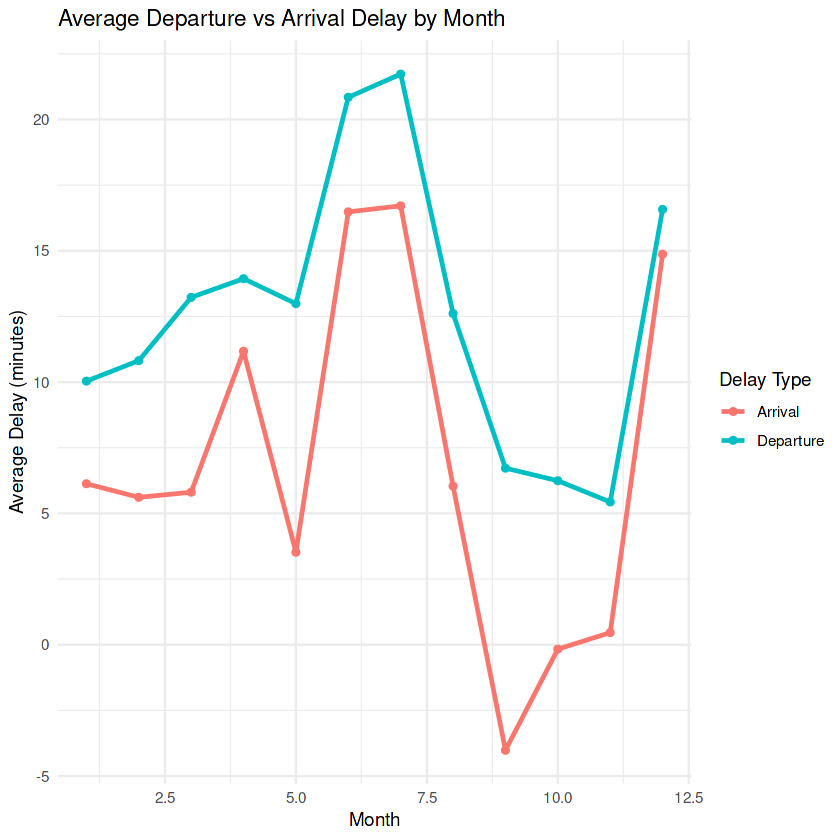

In [20]:
#Average departure vs arrival delay by month
monthly_long <- bind_rows(
  monthly_delays %>% 
    select(month, delay = avg_dep_delay) %>% 
    mutate(type = "Departure"),
  
  monthly_delays %>% 
    select(month, delay = avg_arr_delay) %>% 
    mutate(type = "Arrival")
)
ggplot(monthly_long, aes(x = month, y = delay, color = type)) +
  geom_line(linewidth = 1) +
  geom_point() +
  labs(
    title = "Average Departure vs Arrival Delay by Month",
    x = "Month",
    y = "Average Delay (minutes)",
    color = "Delay Type"
  ) +
  theme_minimal()

#### Average Departure Delay by Month and Hour (heatmap)
This heatmap shows average departure delay by both month and hour of day, highlighting specific times of year and times of day when delays tend to spike together.

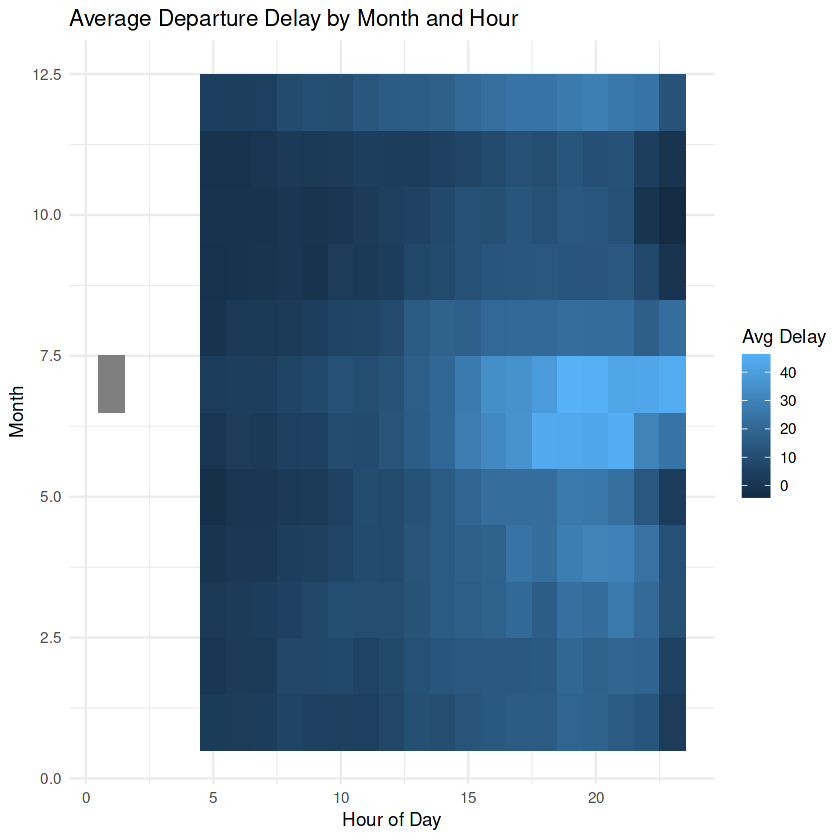

In [21]:
#Average department delay by month and hour
delay_heatmap <- flights %>%
  group_by(month, hour) %>%
  summarise(
    avg_delay = mean(dep_delay, na.rm = TRUE),
    .groups = "drop"
  )
ggplot(delay_heatmap, aes(x = hour, y = month, fill = avg_delay)) +
  geom_tile() +
  labs(
    title = "Average Departure Delay by Month and Hour",
    x = "Hour of Day",
    y = "Month",
    fill = "Avg Delay"
  ) +
  theme_minimal()

#### Aircraft Age vs Departure Delay
This plot examines how departure delays vary with aircraft age to reveal whether older planes tend to experience systematically longer delays than newer aircraft.

`geom_smooth()` using formula = 'y ~ x'


Warning message:
“Removed 69 rows containing non-finite outside the scale range
(`stat_smooth()`).”


Warning message:
“Removed 69 rows containing missing values or values outside the scale range
(`geom_point()`).”


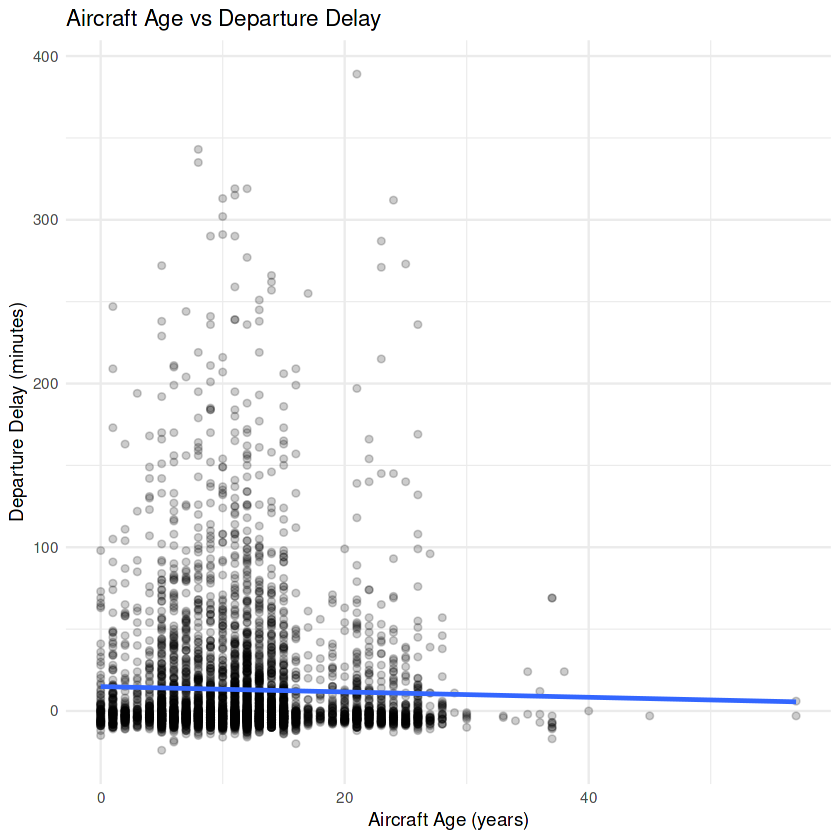

In [22]:
#Aircraft age vs departure delay 
aircraft_delay <- flights %>%
  left_join(planes, by = "tailnum") %>%
  filter(!is.na(year.y)) %>%        # remove missing manufacture year
  mutate(age = 2013 - year.y) %>%   # calculate age
  filter(age >= 0)

set.seed(123)
aircraft_sample <- aircraft_delay %>%
  sample_n(5000)   # 5k points is enough to see trends
ggplot(aircraft_sample, aes(x = age, y = dep_delay)) +
  geom_point(alpha = 0.2) +          # semi-transparent points
  geom_smooth(method = "lm", se = FALSE) +   # linear trend
  labs(
    title = "Aircraft Age vs Departure Delay",
    x = "Aircraft Age (years)",
    y = "Departure Delay (minutes)"
  ) +
  theme_minimal()

Note: Some plots show warnings about rows removed from geom_point()/geom_smooth(); these are expected because rows with missing or extreme delay or weather values are excluded to keep the visualisations clear and interpretable.


#### Departure Delay vs Wind Speed
Here we relate departure delay to wind speed to see whether stronger winds are associated with more severe or more frequent departure delays.

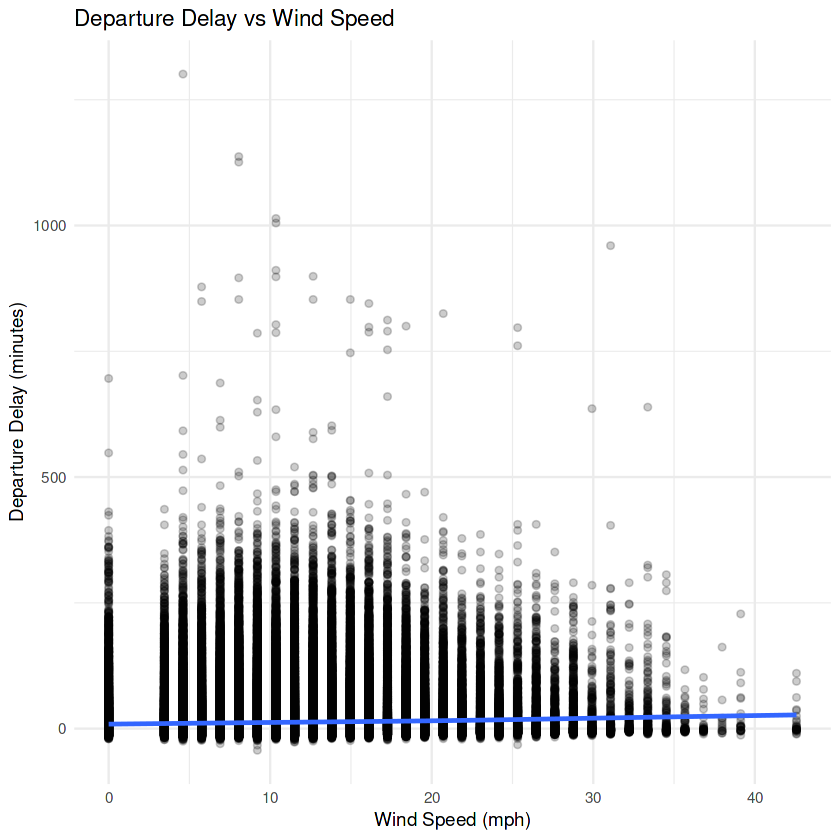

In [23]:
# Departure delay vs wind speed
flights_weather <- flights %>%
  left_join(weather, by = c("year","month","day","hour","origin")) %>%
  filter(!is.na(dep_delay), !is.na(wind_speed))  # drop NAs

ggplot(flights_weather, aes(x = wind_speed, y = dep_delay)) +
  geom_point(alpha = 0.2) +
  geom_smooth(
    method  = "gam",
    formula = y ~ s(x, bs = "cs", k = 5),
    se      = FALSE,
    na.rm   = TRUE
  ) +
  labs(
    title = "Departure Delay vs Wind Speed",
    x     = "Wind Speed (mph)",
    y     = "Departure Delay (minutes)"
  ) +
  theme_minimal()

#### Departure Delay vs Precipitation
This chart explores how departure delays change as precipitation increases, helping to quantify the impact of rain or snow on departure punctuality.

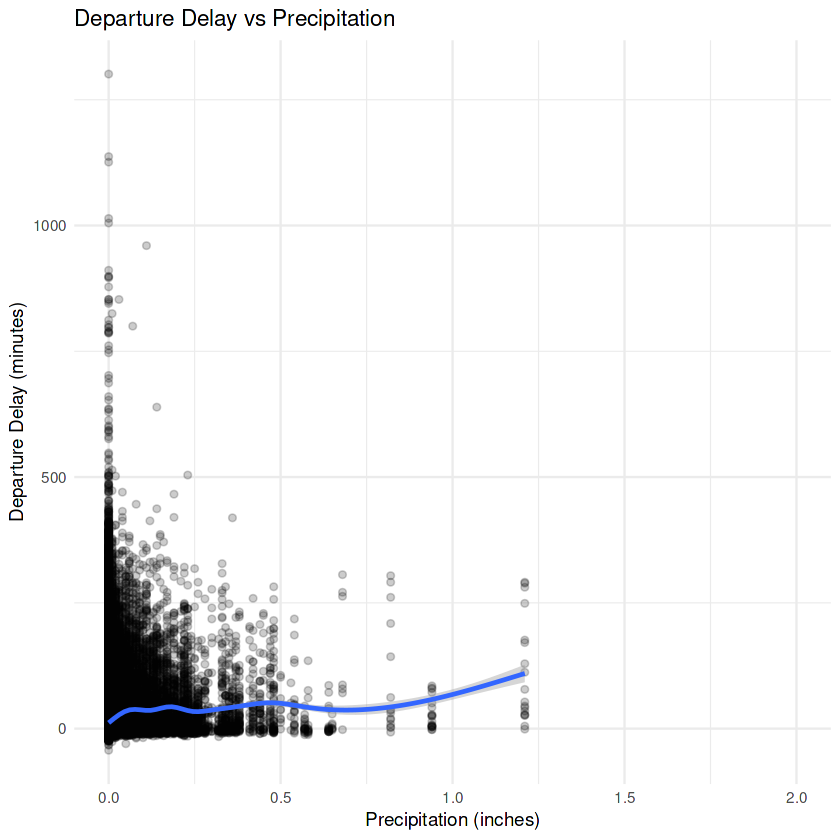

In [24]:

# Departure delay vs precipitation
flights_weather <- flights %>%
  left_join(weather, by = c("year","month","day","hour","origin")) %>%
  filter(!is.na(dep_delay), !is.na(precip))

ggplot(flights_weather, aes(x = precip, y = dep_delay)) +
  geom_point(alpha = 0.2) +
  geom_smooth(
    method = "gam",
    formula = y ~ s(x, bs = "cs"),
    na.rm = TRUE
  ) +
  coord_cartesian(xlim = c(0, 2)) +
  labs(
    title = "Departure Delay vs Precipitation",
    x = "Precipitation (inches)",
    y = "Departure Delay (minutes)"
  ) +
  theme_minimal()



#### Departure Delay vs Visibility
Here we assess how departure delays vary with visibility conditions, showing whether low‑visibility situations are linked to longer or more frequent delays.


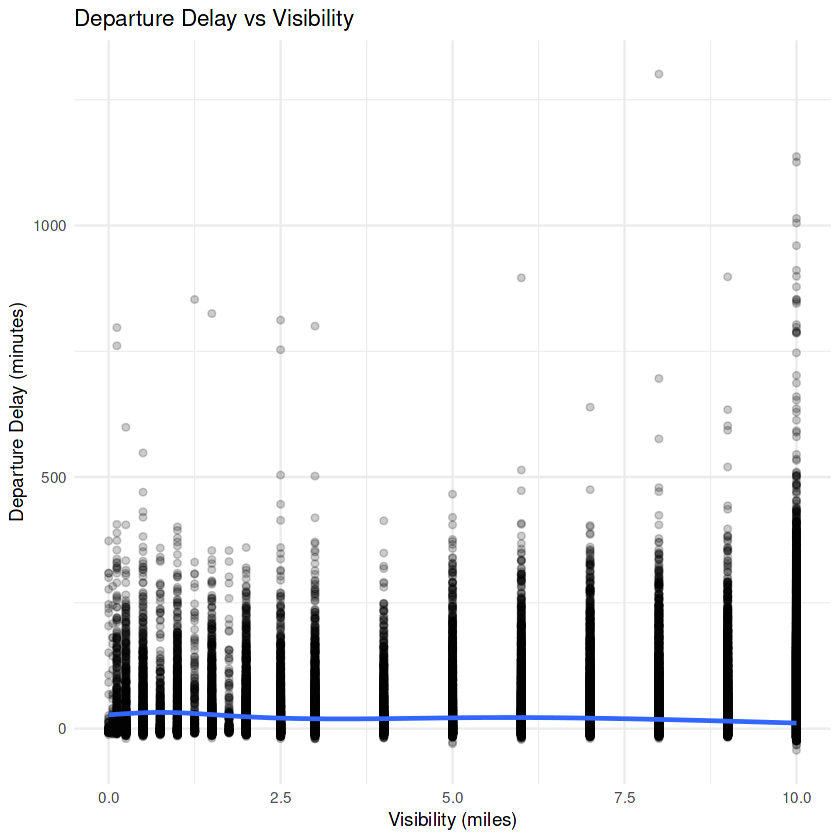

In [25]:
# Departure delay vs visibility
flights_weather <- flights %>%
  left_join(weather, by = c("year", "month", "day", "hour", "origin")) %>%
  filter(!is.na(dep_delay), !is.na(visib))  # explicit filter

ggplot(flights_weather, aes(x = visib, y = dep_delay)) +
  geom_point(alpha = 0.2) +
  geom_smooth(
    method  = "gam",
    formula = y ~ s(x, bs = "cs", k = 5),
    se      = FALSE,
    na.rm   = TRUE
  ) +
  labs(
    title = "Departure Delay vs Visibility",
    x     = "Visibility (miles)",
    y     = "Departure Delay (minutes)"
  ) +
  theme_minimal()

#### Departure Delay vs Weather Factors by Airline
These faceted plots compare how different airlines’ departure delays respond to changes in wind speed, precipitation, and visibility, revealing whether some carriers handle adverse weather more robustly than others.<br>

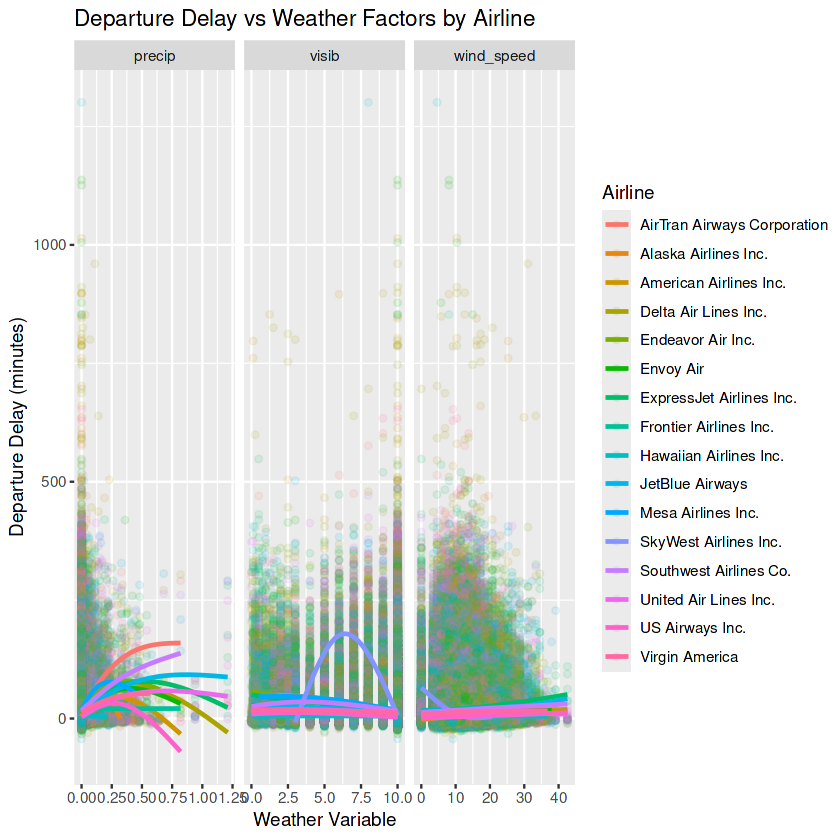

In [26]:
# Departure Delay vs Weather Factors by Airline

# Join flights with weather and airline names
fw_airline <- flights %>%
  left_join(weather,  by = c("year", "month", "day", "hour", "origin")) %>%
  left_join(airlines, by = "carrier") %>%
  filter(!is.na(dep_delay))   # keep flights with recorded departure delay

# Reshape to long format for three weather variables
fw_long <- fw_airline %>%
  select(dep_delay, name, wind_speed, precip, visib) %>%
  pivot_longer(
    cols      = c(wind_speed, precip, visib),
    names_to  = "weather_var",
    values_to = "value"
  ) %>%
  filter(!is.na(value), !is.na(dep_delay))   # drop missing weather or delay

# Faceted scatter + smooth by weather variable and airline
ggplot(fw_long, aes(x = value, y = dep_delay, color = name)) +
  geom_point(alpha = 0.1) +
  geom_smooth(
    method  = "gam",
    formula = y ~ s(x, bs = "cs", k = 3),
    se      = FALSE,
    na.rm   = TRUE
  ) +
  facet_wrap(~ weather_var, scales = "free_x") +
  labs(
    title = "Departure Delay vs Weather Factors by Airline",
    x     = "Weather Variable",
    y     = "Departure Delay (minutes)",
    color = "Airline"
  )


#### Departure Delay vs Flight Distance
This plot shows how departure delays relate to flight distance, highlighting whether short‑haul or long‑haul routes are more prone to extended departure delays.

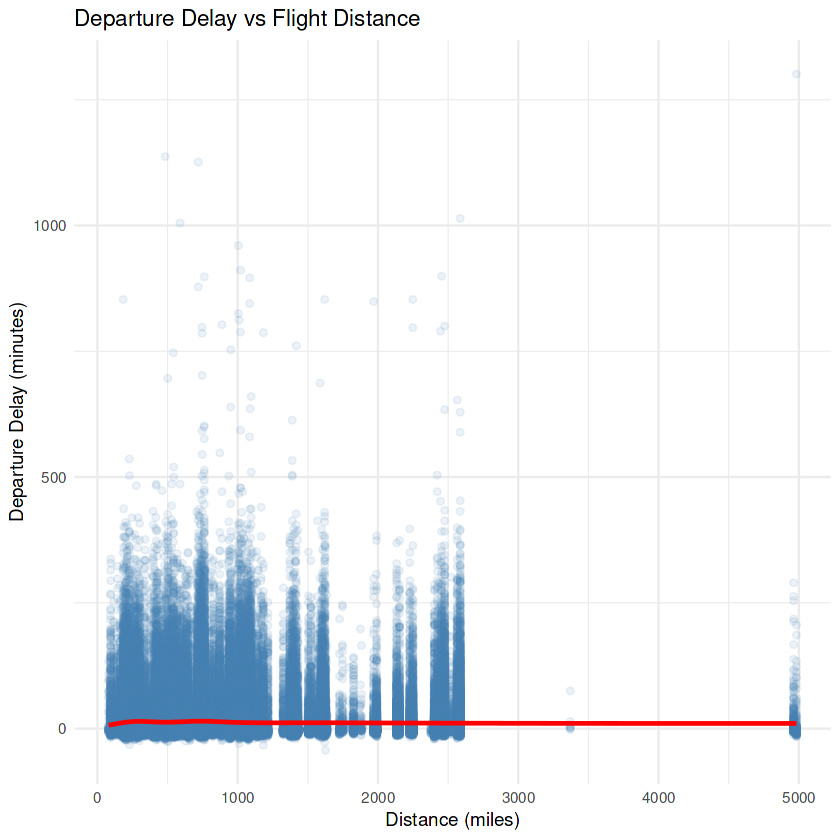

In [27]:
#Departure delay vs flight distance 

#Remove cancelled flights
flights_clean <- flights %>%
  filter(!is.na(dep_delay), !is.na(distance))

#Plot departure delay vs distance
ggplot(flights_clean, aes(x = distance, y = dep_delay)) +
  geom_point(alpha = 0.1, color = "steelblue") +  # transparent points
  geom_smooth(method = "gam", formula = y ~ s(x, bs = "cs"), color = "red") +
  labs(
    title = "Departure Delay vs Flight Distance",
    x = "Distance (miles)",
    y = "Departure Delay (minutes)"
  ) +
  theme_minimal()

# What I learned 


Through this project, I strengthened my end‑to‑end data analysis skills in R, from data cleaning and joining multiple tables (flights, airlines, planes, weather) with dplyr to building a coherent exploratory analysis workflow. 

I practised designing clear visualisations with ggplot2 to answer concrete business questions, such as when delays are worst (by month and hour), how they differ by airline, and how they relate to distance, weather conditions, and aircraft age.

I also improved my ability to communicate insights in Markdown by structuring the notebook as a narrative, summarising key patterns for each plot, and adding a concise conclusion that highlights practical takeaways for decision‑makers.